In [1]:
# @title Running in Colab

from IPython.display import HTML, Javascript, display

display(
    HTML(
        """<a href="https://colab.research.google.com/github/evan-lloyd/mechinterp-experiments/blob/main/tiny_stories_sae/feature_interaction_demo.ipynb" target="_blank" id="colab-button">
            Run this notebook in Google Colab
        </a>"""
    )
)
display(
    Javascript("""
        setTimeout(() => {
            if(typeof google.colab != "undefined") {
                document.querySelector("#colab-button").remove()
            }
        }, 0);
        """)
)

<IPython.core.display.Javascript object>

# Initialize notebook environment

In [2]:
import os

# If we're running in Colab, we need to clone the non-notebook source from git.
if os.getenv("COLAB_RELEASE_TAG") and not os.path.isdir(
    "/content/mechinterp-experiments"
):
    ip = get_ipython()  #  pyright: ignore[reportUndefinedVariable]
    ip.run_cell_magic(
        "bash",
        "",
        """
    git clone --filter=blob:none --no-checkout https://github.com/evan-lloyd/mechinterp-experiments.git
    cd mechinterp-experiments
    git sparse-checkout init --no-cone
    echo "/tiny_stories_sae" > .git/info/sparse-checkout
    git checkout
  """,
    )
    ip.run_line_magic("cd", "mechinterp-experiments/tiny_stories_sae")
else:
    print("Already cloned source, or not running in Colab.")

# Nice for dev, but not needed for Colab.
try:
    # This uses a library called jurigged to hot-reload code when it is changed.
    # For reasons I've never been able to figure out, the IPython %autoreload magic
    # completely fails to work with the kind of structure I use in this notebook.
    import tiny_stories_sae._autoreload
except Exception:
    pass

Already cloned source, or not running in Colab.


In [3]:
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

# Tweak TRAINING_BATCH_SIZE for your hardware if necessary
if torch.cuda.is_available():
    TRAINING_DEVICE = "cuda:0"
    TRAINING_BATCH_SIZE = 16
elif torch.mps.is_available():
    TRAINING_DEVICE = "mps:0"
    TRAINING_BATCH_SIZE = 8
else:
    TRAINING_DEVICE = "cpu"
    TRAINING_BATCH_SIZE = 8

tokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-neo-125M")
training_dataset = load_dataset("roneneldan/TinyStories", split="train", streaming=True)
validation_dataset = load_dataset(
    "roneneldan/TinyStories", split="validation", streaming=True
)
model = AutoModelForCausalLM.from_pretrained("roneneldan/TinyStories-33M").to(
    TRAINING_DEVICE
)

print(model)

GPTNeoForCausalLM(
  (transformer): GPTNeoModel(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(2048, 768)
    (drop): Dropout(p=0.0, inplace=False)
    (h): ModuleList(
      (0-3): 4 x GPTNeoBlock(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPTNeoAttention(
          (attention): GPTNeoSelfAttention(
            (attn_dropout): Dropout(p=0.0, inplace=False)
            (resid_dropout): Dropout(p=0.0, inplace=False)
            (k_proj): Linear(in_features=768, out_features=768, bias=False)
            (v_proj): Linear(in_features=768, out_features=768, bias=False)
            (q_proj): Linear(in_features=768, out_features=768, bias=False)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPTNeoMLP(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (c_proj): Linear(in_feat

In [4]:
# Caches model activations to these directories; modify if necessary, or set to None to disable.
# These take up ~16GB and ~1.5GB respectively, but will save a fair bit of time when running
# the notebook, since they can be re-used across all methods we're comparing.
# Skip caching if CUDA is available, as at least on the cloud hardware I was using it was actually
# faster to just re-run the model than to load from disk! (Possibly my caching implementation is just bad.)
TRAINING_CACHE_DIR = None if torch.cuda.is_available() else ".training_cache"
VALIDATION_CACHE_DIR = None if torch.cuda.is_available() else ".validation_cache"
NUM_TRAINING_TOKENS = int(1e7) if torch.cuda.is_available() else int(1e6)
EVAL_INTERVAL = int(1e5)
NUM_VALIDATION_TOKENS = int(1e6) if torch.cuda.is_available() else int(1e5)
D_MODEL = model.config.hidden_size
D_SAE = D_MODEL * 4
TOPK = 100
TOKENIZER_BATCH_SIZE = 128
FINETUNE_FRACTION = 0.1
# Note this will use up ~1.8GB of space, set to False if you want to skip
SAVE_FINAL_RESULTS = True

# Train SAEs

In [5]:
from itertools import product

import numpy as np

from tiny_stories_sae.sae import (
    SAE,
    DecoderConfig,
    EncoderConfig,
    InteractionEncoderConfig,
    SAEConfig,
    TopKActivationFunctionConfig,
)
from tiny_stories_sae.training import TrainingConfig, TrainingMethod, fine_tune, train
from tiny_stories_sae.validation import run_validations


def SAE_SPECS():
    return product(TrainingMethod, (False, True))


empty_saes = {
    (method, use_interaction): {
        layer: SAE(
            SAEConfig(
                d_model=D_MODEL,
                d_sae=D_SAE,
                device=TRAINING_DEVICE,
                encoder=EncoderConfig(
                    d_model=D_MODEL,
                    d_sae=D_SAE,
                    device=TRAINING_DEVICE,
                    activation_function=TopKActivationFunctionConfig(k=TOPK),
                )
                if not use_interaction
                else InteractionEncoderConfig(
                    d_model=D_MODEL,
                    d_sae=D_SAE,
                    device=TRAINING_DEVICE,
                    activation_function=TopKActivationFunctionConfig(k=TOPK),
                    n_interaction_iterations=1,
                ),
                decoder=DecoderConfig(
                    d_model=D_MODEL,
                    d_sae=D_SAE,
                    device=TRAINING_DEVICE,
                ),
            )
        )
        for layer in range(model.config.num_layers)
    }
    for method, use_interaction in SAE_SPECS()
}


def linear_decay_during_finetune(frac_trained: float):
    if frac_trained < (1 - FINETUNE_FRACTION):
        return 1.0
    return 1.0 - (frac_trained - (1 - FINETUNE_FRACTION)) / FINETUNE_FRACTION


training_config = {
    (method, use_interaction): TrainingConfig(
        tokenizer_batch_size=TOKENIZER_BATCH_SIZE,
        training_batch_size=TRAINING_BATCH_SIZE,
        num_train_tokens=NUM_TRAINING_TOKENS,
        eval_interval=EVAL_INTERVAL,
        train_layers=list(range(model.config.num_layers)),
        lr=1e-3,
        interaction_lr=1e-3,
        lr_schedule=linear_decay_during_finetune,  # per Karvonen (2025)
        downstream_reconstruction_weight=1.0,
        reconstruction_weight=1.0,
        balance_reconstruction_losses=True,
        method=method,
        finetune_fraction=FINETUNE_FRACTION
        if method in (TrainingMethod.finetuned, TrainingMethod.next_layer_finetuned)
        else None,
    )
    for method, use_interaction in SAE_SPECS()
}

training_results = {}
validation_results = {}

In [6]:
import os

from tiny_stories_sae.activation_cache import build_cache

if TRAINING_CACHE_DIR and (
    not os.path.exists(TRAINING_CACHE_DIR) or not os.listdir(TRAINING_CACHE_DIR)
):
    build_cache(
        TRAINING_CACHE_DIR,
        model,
        tokenizer,
        training_dataset,
        tokenizer_batch_size=TOKENIZER_BATCH_SIZE,
        inference_batch_size=TRAINING_BATCH_SIZE,
        num_tokens=NUM_TRAINING_TOKENS,
    )

if VALIDATION_CACHE_DIR and (
    not os.path.exists(VALIDATION_CACHE_DIR) or not os.listdir(VALIDATION_CACHE_DIR)
):
    build_cache(
        VALIDATION_CACHE_DIR,
        model,
        tokenizer,
        validation_dataset,
        tokenizer_batch_size=TOKENIZER_BATCH_SIZE,
        inference_batch_size=TRAINING_BATCH_SIZE,
        num_tokens=NUM_VALIDATION_TOKENS,
    )

In [7]:
for spec in SAE_SPECS():
    # We finetune these from checkpoints of other methods
    if spec[0] in (TrainingMethod.finetuned, TrainingMethod.next_layer_finetuned):
        continue
    print(f"Training {spec[0].value}, use_interaction={spec[1]}")
    training_results[spec] = train(
        model,
        tokenizer,
        empty_saes[spec],
        training_dataset,
        training_config[spec],
        cache_dir=TRAINING_CACHE_DIR,
        checkpoints_at=[int((1.0 - FINETUNE_FRACTION) * NUM_TRAINING_TOKENS)]
        if spec[0] in (TrainingMethod.standard, TrainingMethod.next_layer)
        else None,
    )
    validation_results[spec] = run_validations(
        model,
        tokenizer,
        training_results[spec].final_saes,
        validation_dataset,
        num_tokens=NUM_VALIDATION_TOKENS,
        tokenizer_batch_size=training_config[spec].tokenizer_batch_size,
        inference_batch_size=training_config[spec].training_batch_size,
        cache_dir=VALIDATION_CACHE_DIR,
    )
    print(
        f"mean rre={ {k: np.mean(v.rre).item() for k, v in validation_results[spec].layer_results.items() if v.rre is not None} })"
    )
    print(
        f"geom mean kl={ {k: np.exp(np.mean(np.log(v.kl[v.kl > 0]))).item() for k, v in validation_results[spec].layer_results.items() if v.kl is not None} })"
    )

Training Standard, use_interaction=False


Layer 3

  0%|          | 0/10000000 [00:00<?, ?it/s]

Layer 2

  0%|          | 0/10000000 [00:00<?, ?it/s]

...

  0%|          | 0/10000000 [00:00<?, ?it/s]

Layer 0

  0%|          | 0/10000000 [00:00<?, ?it/s]

Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

mean rre={0: 0.27076607942581177, 1: 0.3436647057533264, 2: 0.47654250264167786, 3: 0.8271929621696472})
geom mean kl={4: 0.1260274052619934})


In [8]:
for spec in SAE_SPECS():
    if spec[0] not in (TrainingMethod.finetuned, TrainingMethod.next_layer_finetuned):
        continue
    print(f"Training {spec[0].value}, use_interaction={spec[1]}")
    training_results[spec] = fine_tune(
        model,
        tokenizer,
        training_results[
            (
                TrainingMethod.standard
                if spec[0] == TrainingMethod.finetuned
                else TrainingMethod.next_layer,
                spec[1],
            )
        ],
        0,
        training_dataset,
        training_config[spec],
        cache_dir=TRAINING_CACHE_DIR,
    )
    validation_results[spec] = run_validations(
        model,
        tokenizer,
        training_results[spec].final_saes,
        validation_dataset,
        num_tokens=NUM_VALIDATION_TOKENS,
        tokenizer_batch_size=training_config[spec].tokenizer_batch_size,
        inference_batch_size=training_config[spec].training_batch_size,
        cache_dir=VALIDATION_CACHE_DIR,
    )
    print(
        f"mean rre={ {k: np.mean(v.rre).item() for k, v in validation_results[spec].layer_results.items() if v.rre is not None} })"
    )
    print(
        f"geom mean kl={ {k: np.exp(np.mean(np.log(v.kl[v.kl > 0]))).item() for k, v in validation_results[spec].layer_results.items() if v.kl is not None} })"
    )


Training KL Fine-tuning, use_interaction=False


Layer 3

  0%|          | 0/994735 [00:00<?, ?it/s]

Layer 2

  0%|          | 0/994735 [00:00<?, ?it/s]

...

  0%|          | 0/994735 [00:00<?, ?it/s]

Layer 0

  0%|          | 0/994735 [00:00<?, ?it/s]

Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

mean rre={0: 0.2069324254989624, 1: 0.2907637655735016, 2: 0.4015311896800995, 3: 0.638978123664856})
geom mean kl={4: 0.10956151783466339})


In [31]:
# Print KL statistics as an HTML table
from tiny_stories_sae.ops import display_sortable_html_table

headers = [
    "Layer",
    "Method",
    "Interaction",
    "Geometric Mean KL",
    "GSD Lower",
    "GSD Upper",
]
rows = []

for layer in [model.config.num_layers]:
    for spec, results in validation_results.items():
        if layer not in results.layer_results:
            continue

        interaction_label = "Yes" if spec[1] else "No"
        kl_values = results.layer_results[layer].kl
        kl_positive = np.clip(kl_values, min=1e-9)
        log_kl = np.log(kl_positive)
        log_mean = np.mean(log_kl)
        log_std = np.std(log_kl)
        gm = np.exp(log_mean)
        gsd = np.exp(log_std)
        gsd_lower = gm - gm / gsd
        gsd_upper = gm * gsd - gm

        rows.append(
            [
                layer,
                spec[0].value,
                interaction_label,
                f"{gm:.6f}",
                f"{gsd_lower:.6f}",
                f"{gsd_upper:.6f}",
            ]
        )

display_sortable_html_table(headers, rows)

Layer ⇅,Method ⇅,Interaction ⇅,Geometric Mean KL ⇅,GSD Lower ⇅,GSD Upper ⇅
4,Standard,No,0.181872,0.170908,2.835064
4,Standard,Yes,0.150463,0.140935,2.225745
4,Next Layer,No,0.131193,0.120960,1.550719
4,Next Layer,Yes,0.114676,0.105774,1.362633
4,End-to-end,No,0.147677,0.133830,1.427310
4,End-to-end,Yes,0.126025,0.114675,1.273248
4,KL Fine-tuning,No,0.188214,0.168527,1.611247
4,KL Fine-tuning,Yes,0.162741,0.146804,1.499080
4,Next Layer + Fine-Tuning,No,0.124087,0.114128,1.422012
4,Next Layer + Fine-Tuning,Yes,0.109560,0.100810,1.262288


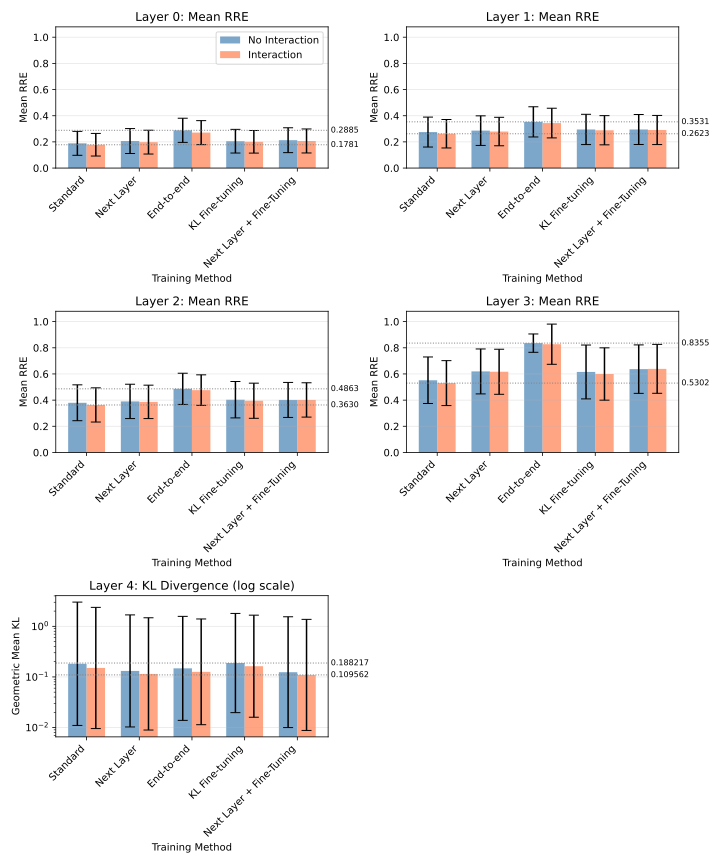

In [32]:
import matplotlib.pyplot as plt
import numpy as np

from tiny_stories_sae.ops import current_plot_to_svg

num_plots = model.config.num_layers + 1
num_cols = 2
num_rows = (num_plots + num_cols - 1) // num_cols
fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
axes = axes.flatten()

plot_idx = 0

# Group specs by method
methods = []
seen_methods = set()
for spec in validation_results:
    if spec[0] not in seen_methods:
        methods.append(spec[0])
        seen_methods.add(spec[0])

method_labels = [m.value for m in methods]
x = np.arange(len(methods))
bar_width = 0.35

colors = {'no_interaction': 'steelblue', 'interaction': 'coral'}

# Plot RRE bar charts for each layer
# First pass: compute global max for RRE across all layers
rre_max = 0
for layer in range(model.config.num_layers):
    for method in methods:
        for use_interaction in [False, True]:
            spec = (method, use_interaction)
            if spec in validation_results and layer in validation_results[spec].layer_results:
                rre_values = validation_results[spec].layer_results[layer].rre
                if rre_values is not None and len(rre_values) > 0:
                    rre_max = max(rre_max, np.mean(rre_values) + np.std(rre_values))

for layer in range(model.config.num_layers):
    ax = axes[plot_idx]
    means_no_int = []
    stds_no_int = []
    means_int = []
    stds_int = []
    
    for method in methods:
        # No interaction
        spec_no_int = (method, False)
        if spec_no_int in validation_results and layer in validation_results[spec_no_int].layer_results:
            rre_values = validation_results[spec_no_int].layer_results[layer].rre
            if rre_values is not None and len(rre_values) > 0:
                means_no_int.append(np.mean(rre_values))
                stds_no_int.append(np.std(rre_values))
            else:
                means_no_int.append(0)
                stds_no_int.append(0)
        else:
            means_no_int.append(0)
            stds_no_int.append(0)
        
        # With interaction
        spec_int = (method, True)
        if spec_int in validation_results and layer in validation_results[spec_int].layer_results:
            rre_values = validation_results[spec_int].layer_results[layer].rre
            if rre_values is not None and len(rre_values) > 0:
                means_int.append(np.mean(rre_values))
                stds_int.append(np.std(rre_values))
            else:
                means_int.append(0)
                stds_int.append(0)
        else:
            means_int.append(0)
            stds_int.append(0)
    
    ax.bar(x - bar_width/2, means_no_int, bar_width, yerr=stds_no_int, capsize=5, alpha=0.7, 
           color=colors['no_interaction'], label='No Interaction')
    ax.bar(x + bar_width/2, means_int, bar_width, yerr=stds_int, capsize=5, alpha=0.7,
           color=colors['interaction'], label='Interaction')
    ax.set_xlabel("Training Method")
    ax.set_ylabel("Mean RRE")
    ax.set_title(f"Layer {layer}: Mean RRE")
    ax.set_xticks(x)
    ax.set_xticklabels(method_labels, rotation=45, ha='right')
    ax.set_ylim(0, rre_max * 1.1)
    ax.grid(True, alpha=0.3, axis='y')
    if plot_idx == 0:
        ax.legend()
    
    # Add horizontal dotted lines at highest and lowest values
    all_means = means_no_int + means_int
    non_zero_means = [m for m in all_means if m > 0]
    if non_zero_means:
        max_val = max(non_zero_means)
        min_val = min(non_zero_means)
        ax.axhline(y=max_val, color='gray', linestyle=':', linewidth=1)
        ax.axhline(y=min_val, color='gray', linestyle=':', linewidth=1)
        ax.text(ax.get_xlim()[1] + 0.05, max_val, f'{max_val:.4f}', va='center', fontsize=8)
        ax.text(ax.get_xlim()[1] + 0.05, min_val, f'{min_val:.4f}', va='center', fontsize=8)
    
    plot_idx += 1

# Plot KL bar charts in log-space for each layer that has it
for layer in [model.config.num_layers]:
    ax = axes[plot_idx]
    gmeans_no_int = []
    gstd_lower_no_int = []
    gstd_upper_no_int = []
    gmeans_int = []
    gstd_lower_int = []
    gstd_upper_int = []
    
    for method in methods:
        # No interaction
        spec_no_int = (method, False)
        if spec_no_int in validation_results and layer in validation_results[spec_no_int].layer_results:
            kl_values = validation_results[spec_no_int].layer_results[layer].kl
            if kl_values is not None and len(kl_values) > 0:
                kl_positive = kl_values[kl_values > 0]
                if len(kl_positive) > 0:
                    log_kl = np.log(kl_positive)
                    log_mean = np.mean(log_kl)
                    log_std = np.std(log_kl)
                    gm = np.exp(log_mean)
                    gmeans_no_int.append(gm)
                    gsd = np.exp(log_std)
                    gstd_lower_no_int.append(gm - gm / gsd)
                    gstd_upper_no_int.append(gm * gsd - gm)
                else:
                    gmeans_no_int.append(0)
                    gstd_lower_no_int.append(0)
                    gstd_upper_no_int.append(0)
            else:
                gmeans_no_int.append(0)
                gstd_lower_no_int.append(0)
                gstd_upper_no_int.append(0)
        else:
            gmeans_no_int.append(0)
            gstd_lower_no_int.append(0)
            gstd_upper_no_int.append(0)
        
        # With interaction
        spec_int = (method, True)
        if spec_int in validation_results and layer in validation_results[spec_int].layer_results:
            kl_values = validation_results[spec_int].layer_results[layer].kl
            if kl_values is not None and len(kl_values) > 0:
                kl_positive = kl_values[kl_values > 0]
                if len(kl_positive) > 0:
                    log_kl = np.log(kl_positive)
                    log_mean = np.mean(log_kl)
                    log_std = np.std(log_kl)
                    gm = np.exp(log_mean)
                    gmeans_int.append(gm)
                    gsd = np.exp(log_std)
                    gstd_lower_int.append(gm - gm / gsd)
                    gstd_upper_int.append(gm * gsd - gm)
                else:
                    gmeans_int.append(0)
                    gstd_lower_int.append(0)
                    gstd_upper_int.append(0)
            else:
                gmeans_int.append(0)
                gstd_lower_int.append(0)
                gstd_upper_int.append(0)
        else:
            gmeans_int.append(0)
            gstd_lower_int.append(0)
            gstd_upper_int.append(0)
    
    ax.bar(x - bar_width/2, gmeans_no_int, bar_width, yerr=[gstd_lower_no_int, gstd_upper_no_int], 
           capsize=5, alpha=0.7, color=colors['no_interaction'], label='No Interaction')
    ax.bar(x + bar_width/2, gmeans_int, bar_width, yerr=[gstd_lower_int, gstd_upper_int],
           capsize=5, alpha=0.7, color=colors['interaction'], label='Interaction')
    ax.set_yscale('log')
    ax.set_xlabel("Training Method")
    ax.set_ylabel("Geometric Mean KL")
    ax.set_title(f"Layer {layer}: KL Divergence (log scale)")
    ax.set_xticks(x)
    ax.set_xticklabels(method_labels, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    # ax.legend()
    
    # Add horizontal dotted lines at highest and lowest values
    all_gmeans = gmeans_no_int + gmeans_int
    non_zero_gmeans = [m for m in all_gmeans if m > 0]
    if non_zero_gmeans:
        max_val = max(non_zero_gmeans)
        min_val = min(non_zero_gmeans)
        ax.axhline(y=max_val, color='gray', linestyle=':', linewidth=1)
        ax.axhline(y=min_val, color='gray', linestyle=':', linewidth=1)
        ax.text(ax.get_xlim()[1] + 0.05, max_val, f'{max_val:.6f}', va='center', fontsize=8)
        ax.text(ax.get_xlim()[1] + 0.05, min_val, f'{min_val:.6f}', va='center', fontsize=8)
    
    plot_idx += 1

# Hide any unused axes
for i in range(plot_idx, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
current_plot_to_svg()

In [30]:
# Print RRE statistics as an HTML table
from tiny_stories_sae.ops import display_sortable_html_table

headers = ["Layer", "Method", "Interaction", "Mean RRE", "Std RRE"]
rows = []

for layer in range(model.config.num_layers):
    for spec, results in validation_results.items():
        if layer not in results.layer_results:
            continue
        interaction_label = "Yes" if spec[1] else "No"

        rre_values = results.layer_results[layer].rre
        mean_rre = np.mean(rre_values)
        std_rre = np.std(rre_values)

        rows.append(
            [
                layer,
                spec[0].value,
                interaction_label,
                f"{mean_rre:.6f}",
                f"{std_rre:.6f}",
            ]
        )

display_sortable_html_table(headers, rows)

Layer ⇅,Method ⇅,Interaction ⇅,Mean RRE ⇅,Std RRE ⇅
0,Standard,No,0.189077,0.091446
0,Standard,Yes,0.178051,0.086360
0,Next Layer,No,0.206530,0.095325
0,Next Layer,Yes,0.198225,0.090824
0,End-to-end,No,0.288453,0.092355
0,End-to-end,Yes,0.270766,0.091619
0,KL Fine-tuning,No,0.205148,0.090538
0,KL Fine-tuning,Yes,0.200867,0.086375
0,Next Layer + Fine-Tuning,No,0.212721,0.094971
0,Next Layer + Fine-Tuning,Yes,0.206932,0.091752


In [13]:
from tiny_stories_sae.ops import save_training_result, ensure_directory

if SAVE_FINAL_RESULTS:
    ensure_directory(".checkpoints")
    ensure_directory(".checkpoints/feature_interaction_demo")
    for spec in training_results.keys():
        save_training_result(
            training_results[spec],
            f".checkpoints/feature_interaction_demo/{spec[0].name}{'_interaction' if spec[1] else ''}",
        )

In [23]:
from tiny_stories_sae.validation import run_single_layer_replacements

single_layer_validations = {}
for spec in validation_results.keys():
    print(spec)
    single_layer_validations[spec] = run_single_layer_replacements(
        model,
        tokenizer,
        training_results[spec].final_saes,
        validation_dataset,
        num_tokens=NUM_VALIDATION_TOKENS,
        tokenizer_batch_size=training_config[spec].tokenizer_batch_size,
        inference_batch_size=training_config[spec].training_batch_size,
        cache_dir=VALIDATION_CACHE_DIR,
    )

(<TrainingMethod.standard: 'Standard'>, False)


Running SAE evals (layer 0):   0%|          | 0/1000000 [00:00<?, ?it/s]

Running SAE evals (layer 1):   0%|          | 0/1000000 [00:00<?, ?it/s]

Running SAE evals (layer 2):   0%|          | 0/1000000 [00:00<?, ?it/s]

Running SAE evals (layer 3):   0%|          | 0/1000000 [00:00<?, ?it/s]

...

(<TrainingMethod.next_layer_finetuned: 'Next Layer + Fine-Tuning'>, True)


Running SAE evals (layer 0):   0%|          | 0/1000000 [00:00<?, ?it/s]

Running SAE evals (layer 1):   0%|          | 0/1000000 [00:00<?, ?it/s]

Running SAE evals (layer 2):   0%|          | 0/1000000 [00:00<?, ?it/s]

Running SAE evals (layer 3):   0%|          | 0/1000000 [00:00<?, ?it/s]

In [27]:
# Print KL statistics as an HTML table
from tiny_stories_sae.ops import display_sortable_html_table

headers = ["Layer", "Method", "Interaction", "Geometric Mean KL", "GSD Lower", "GSD Upper"]
rows = []

for layer in range(model.config.num_layers):
    for spec, result in single_layer_validations.items():
        if layer not in result.layer_results:
            continue

        interaction_label = "Yes" if spec[1] else "No"
        
        kl_values = result.layer_results[layer].kl
        kl_positive = np.clip(kl_values, min=1e-9)
        log_kl = np.log(kl_positive)
        log_mean = np.mean(log_kl)
        log_std = np.std(log_kl)
        gm = np.exp(log_mean)
        gsd = np.exp(log_std)
        gsd_lower = gm - gm / gsd
        gsd_upper = gm * gsd - gm
        
        rows.append([layer, spec[0].value, interaction_label, f"{gm:.6f}", f"{gsd_lower:.6f}", f"{gsd_upper:.6f}"])

display_sortable_html_table(headers, rows)

Layer ⇅,Method ⇅,Interaction ⇅,Geometric Mean KL ⇅,GSD Lower ⇅,GSD Upper ⇅
0,Standard,No,0.020633,0.019545,0.370748
0,Standard,Yes,0.018068,0.017120,0.326408
0,Next Layer,No,0.021036,0.019770,0.328649
0,Next Layer,Yes,0.019105,0.017932,0.292186
0,End-to-end,No,0.024560,0.022924,0.344314
0,End-to-end,Yes,0.021417,0.019994,0.301025
0,KL Fine-tuning,No,0.023968,0.022061,0.277220
0,KL Fine-tuning,Yes,0.022519,0.020813,0.274782
0,Next Layer + Fine-Tuning,No,0.023392,0.021716,0.303005
0,Next Layer + Fine-Tuning,Yes,0.021628,0.020146,0.293911


In [28]:
from tiny_stories_sae.validation import generate_with_replacement
from IPython.display import HTML

# Generate completions with and without SAE replacement
prompt = "Once upon a time"
sample_generations = {}

# Generate without replacement (baseline)
print("Generating baseline completion...")
baseline_tokens = generate_with_replacement(
    model, tokenizer, prompt, saes={}, do_sample=False, stream=False
)
sample_generations["Baseline"] = tokenizer.decode(
    baseline_tokens[0], skip_special_tokens=True
)

# Generate with each SAE method
for spec, results in training_results.items():
    print(f"Generating completion with {spec[0].value}...")
    method_tokens = generate_with_replacement(
        model,
        tokenizer,
        prompt,
        saes=results.final_saes,
        do_sample=False,
        stream=False,
    )
    sample_generations[spec[0].value] = tokenizer.decode(
        method_tokens[0], skip_special_tokens=True
    )

# Display results in HTML table
html_table = """
<table border="1" style="border-collapse: collapse; width: 100%;">
<tr style="background-color: #f2f2f2;">
<th style="padding: 10px; text-align: left;">Method</th>
<th style="padding: 10px; text-align: left;">Generated Text</th>
</tr>
"""

for method_name, text in sample_generations.items():
    html_table += f"""
<tr>
<td style="padding: 10px; vertical-align: top; font-weight: bold;">{method_name}</td>
<td style="padding: 10px; font-family: monospace; white-space: pre-wrap;">{text}</td>
</tr>
"""

html_table += "</table>"

display(HTML(html_table))


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generating baseline completion...


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generating completion with Standard...


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


...

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generating completion with Next Layer + Fine-Tuning...


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generating completion with Next Layer + Fine-Tuning...


Method,Generated Text
Baseline,"Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she saw a big, red apple on the ground. She picked it up and took a bite. It was so juicy and delicious! Suddenly, she heard a loud noise. It was a big, scary dog! Lily was scared and didn't know what to do. But then, she remembered the apple she had picked earlier. She took a bite and it was even more delicious than before! Lily learned that sometimes things that look scary can be delicious. She also learned that it's important to be brave and not give up. From that day on, Lily always carried an apple with her, just in case she needed to face her fears."
Standard,"Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she saw a big, scary spider crawling around her. She was scared of the spider and ran away. Lily's mom saw her running and asked, ""What are you doing?"" Lily replied, ""I'm scared of the spider!"" Her mom said, ""Don't worry, Lily. I'm not so scary. Let's go play together."" Lily's mom said, ""Let's go play together in the park."" They went to the park and played on the swings and slide. Lily was happy she had her mom to help her. From that day on, Lily wasn't scared of spiders anymore."
Next Layer,"Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she found a shiny rock and wanted to keep it. But her mom told her that it was time to go inside and put the rock back in the box. Lily was sad because she wanted to keep the rock. But her mom said it was time to go inside and wash her hands. Lily didn't want to leave her rock, but she knew she had to listen to her mom. When they got inside, Lily's mom told her that it was time to put her rock back in the box. Lily was sad, but she knew she had to listen to her mom. She put the rock back in the box and her mom said they could go back outside and play again tomorrow."
End-to-end,"Once upon a time, there was a little girl named Lily. She loved to play outside in the park with her friends. One day, they saw a big, scary dog running towards them. Lily's friend, Timmy, said, ""Don't worry, I'll protect you."" Lily was scared, but Timmy was very brave. He stood up and said, ""I'll protect you. I'm not scared of the dog. I'm brave."" Lily felt happy and grateful for Timmy's bravery. She said, ""Thank you, Timmy. You're my friend."" After that day, Lily and Timmy played together every day. They had so much fun and learned that it's important to be brave and protect others."
KL Fine-tuning,"Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she saw a big tree with lots of leaves. She wanted to climb it, but she was too small. Lily's mom said, ""Lily, come back down from the tree. It's not time to come down now."" Lily said, ""But I want to climb the tree!"" Her mom said, ""No, Lily. You're too small. I don't want you to climb the tree. You're too small."" Lily was sad, but she listened to her mom. She went back down from the tree and played with her toys. Later that day, Lily went to the park with her mom. She saw a big slide and wanted to try it out. She climbed up the ladder and slid down the slide. She was so happy! But then, Lily saw a boy who was very rude. He was mean to her and took her favorite toy. Lily was very sad and cried. Her mom came over and said, ""Lily, it's okay. It's not nice to be rude to others. We can go get some ice cream instead."" Lily felt better and went to get ice cream. She was happy again and went back to the tree to play."
Next Layer + Fine-Tuning,"Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she went to the park with her mommy and saw a big, beautiful butterfly. She wanted to catch it, but her mommy said, ""No, Lily. We can't catch the butterfly. It's too high up in the sky."" Lily was sa

In [22]:
from tiny_stories_sae.ops import save_training_result, ensure_directory

if SAVE_FINAL_RESULTS:
    ensure_directory(".checkpoints")
    ensure_directory(".checkpoints/feature_interaction_demo")
    for spec in training_results.keys():
        save_training_result(
            training_results[spec],
            f".checkpoints/feature_interaction_demo/{spec[0].name}{'_interaction' if spec[1] else ''}",
        )

In [ ]:
# from tiny_stories_sae.ops import load_training_result

# loaded_saes = {
#     k: v.change_configured_device(TRAINING_DEVICE)
#     for k, v in load_training_result(
#         ".checkpoints/feature_interaction_demo/e2e"
#     ).final_saes.items()
# }